In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **데이터 구조화**

- 데이터 분석에서 데이터의 구조는 분석의 정확성과 효율성을 좌우함.
- 잘못된 데이터 구조는 분석과 시각화 작업을 어렵게 만들고, 데이터를 변환하지 않으면 다양한 분석 도구와 호환되지 않음.
- 분석에 적합한 구조는 데이터를 효율적으로 다룰 수 있으며, 원하는 인사이트를 쉽게 얻을 수 있음.

### **1. 잘못된 데이터 구조 (Wide Format)**
- 잘못된 구조의 데이터는 흔히 **넓은 형식(Wide Format)** 으로 되어 있으며, 다음과 같은 문제를 가짐
    - 열이 많고 중복됨: 동일한 변수(예: 판매량, 매출액)에 대해 여러 열로 나뉘어 있어 분석에 적합하지 않음.
    - 데이터의 중복: 분기별로 데이터가 각 열에 중복되어 있어 데이터가 복잡하게 보임.
    - 데이터 조작 어려움: 피벗 테이블, 그룹화 등의 기능을 바로 적용하기 어렵고, 시각화 도구에서도 비효율적임.

In [4]:
df = pd.read_csv('./pandas_09_분기별매출액.csv')
df

,Unnamed: 0,제품,Q1_판매량,Q1_매출액,Q2_판매량,Q2_매출액,Q3_판매량,Q3_매출액
0,0,삼성 갤럭시 S21,100,1000000,110,1100000,130,1300000
1,1,LG OLED TV,150,1500000,160,1600000,180,1800000
2,2,애플 아이폰 12,200,2000000,210,2100000,230,2300000


**문제점**
- 각 분기별 판매량과 매출액이 별도 열로 분리되어 있어 분석 및 시각화가 복잡해짐.
- 각 열을 대상으로 분기별 집계나 분석을 하기 어렵고, 데이터를 변환하지 않으면 그룹화, 집계 함수 적용이 불편함.

### **2. 분석에 적합한 데이터 구조 (Long Format)**
- **긴 형식(Long Format)** 은 데이터 분석 및 시각화에 적합한 형태로, 다음과 같은 장점이 있음:
    - 데이터가 세분화됨: 열이 아닌 행을 기준으로 데이터가 나열되어 있어, 데이터를 쉽게 그룹화하거나 피벗 테이블로 요약할 수 있음.
    - 중복 최소화: 동일한 제품에 대한 정보가 각 열에 중복되지 않고, 데이터가 깔끔하게 정리됨.
    - 분석 도구와의 호환성: 다양한 분석 도구 및 라이브러리에서 긴 형식의 데이터를 다루기 쉬움

In [5]:
# 데이터를 분석에 적합한 형태로 변환 (melt 사용)
df_long = pd.melt(df, id_vars=['제품'], 
                  value_vars=['Q1_판매량', 'Q1_매출액', 'Q2_판매량', 'Q2_매출액', 'Q3_판매량', 'Q3_매출액'],
                  var_name='분기_항목', value_name='값')

# 분기와 항목을 분리하여 열을 추가
df_long[['분기', '항목']] = df_long['분기_항목'].str.split('_', expand=True)

# 불필요한 '분기_항목' 열 삭제
df_long.drop(columns=['분기_항목'], inplace=True)

# 변환된 데이터 확인
df_long

,제품,값,분기,항목
0,삼성 갤럭시 S21,100,Q1,판매량
1,LG OLED TV,150,Q1,판매량
2,애플 아이폰 12,200,Q1,판매량
3,삼성 갤럭시 S21,1000000,Q1,매출액
4,LG OLED TV,1500000,Q1,매출액
5,애플 아이폰 12,2000000,Q1,매출액
6,삼성 갤럭시 S21,110,Q2,판매량
7,LG OLED TV,160,Q2,판매량
8,애플 아이폰 12,210,Q2,판매량
9,삼성 갤럭시 S21,1100000,Q2,매출액


## **melt() 함수**
- **넓은 형식(wide format)** 에서 **긴 형식(long format)** 으로 변환하는 데 사용함.
- 여러 열에 흩어져 있는 데이터를 하나의 열로 합쳐 세분화된 데이터를 다룰 수 있게 해줌.

**파라미터**
- id_vars: 변환 과정에서 유지할 열을 지정함. 이 열은 변환 후에도 그대로 유지됨.
- value_vars: 여러 열을 하나로 합쳐서 변환할 열을 지정함. 이 파라미터를 지정하지 않으면, id_vars를 제외한 모든 열이 변환됨
- var_name: 변환 후 열 이름이 저장될 열의 이름을 지정함. 각 열의 이름
- value_name: 변환 후 값이 저장될 열의 이름을 지정함. 기존 데이터의 값(판매량, 매출액 등)이 이 열에 저장됨.

#### **a.기본 사용법: 여러 열을 하나로 변환**

In [9]:
df = pd.read_csv('./pandas_09_melt.csv', index_col=0)
df

,제품,Q1_판매량,Q2_판매량,Q3_판매량
0,삼성 갤럭시 S21,100,110,130
1,LG OLED TV,150,160,180
2,애플 아이폰 12,200,210,230


In [10]:
# melt 사용: 여러 열을 하나의 열로 변환
# 모든 데이터를 long format으로 변환
df_melt = pd.melt(df)
df_melt

,variable,value
0,제품,삼성 갤럭시 S21
1,제품,LG OLED TV
2,제품,애플 아이폰 12
3,Q1_판매량,100
4,Q1_판매량,150
5,Q1_판매량,200
6,Q2_판매량,110
7,Q2_판매량,160
8,Q2_판매량,210
9,Q3_판매량,130


In [11]:
# id_vars : 고정할 열을 선택
df_melt = pd.melt(df, id_vars='제품')
df_melt

,제품,variable,value
0,삼성 갤럭시 S21,Q1_판매량,100
1,LG OLED TV,Q1_판매량,150
2,애플 아이폰 12,Q1_판매량,200
3,삼성 갤럭시 S21,Q2_판매량,110
4,LG OLED TV,Q2_판매량,160
5,애플 아이폰 12,Q2_판매량,210
6,삼성 갤럭시 S21,Q3_판매량,130
7,LG OLED TV,Q3_판매량,180
8,애플 아이폰 12,Q3_판매량,230


In [12]:
# 변환 한 열의 이름 설정, 
# var_name : columns -> 값으로 변경할 시 컬럼명
# value_name : value -> 값으로 변경할 시 컬럼명

df_melt = pd.melt(df, id_vars='제품', var_name='분기', value_name='판매량')
df_melt

,제품,분기,판매량
0,삼성 갤럭시 S21,Q1_판매량,100
1,LG OLED TV,Q1_판매량,150
2,애플 아이폰 12,Q1_판매량,200
3,삼성 갤럭시 S21,Q2_판매량,110
4,LG OLED TV,Q2_판매량,160
5,애플 아이폰 12,Q2_판매량,210
6,삼성 갤럭시 S21,Q3_판매량,130
7,LG OLED TV,Q3_판매량,180
8,애플 아이폰 12,Q3_판매량,230


#### **b. 여러 값이 있는 열을 하나로 합치기**
- 여러 개의 판매량과 매출액 같은 서로 다른 값이 존재하는 열을 하나로 합치는 경우.

In [20]:
df = pd.read_csv('./pandas_09_melt2.csv', index_col=0)

In [21]:
# melt 사용: 판매량과 매출액을 하나로 변환
df_melt = pd.melt(df, id_vars='제품', var_name='분기_항목', value_name='값')
df_melt

,제품,분기_항목,값
0,삼성 갤럭시 S21,Q1_판매량,100
1,LG OLED TV,Q1_판매량,150
2,애플 아이폰 12,Q1_판매량,200
3,삼성 갤럭시 S21,Q1_매출액,1000000
4,LG OLED TV,Q1_매출액,1500000
5,애플 아이폰 12,Q1_매출액,2000000
6,삼성 갤럭시 S21,Q2_판매량,110
7,LG OLED TV,Q2_판매량,160
8,애플 아이폰 12,Q2_판매량,210
9,삼성 갤럭시 S21,Q2_매출액,1100000


In [22]:
# 분기와 항목열 생성
# 분기_항목 열을 str : 문자열을 편집하는 메소드, split은 문자를 나누기, expand는 각각의 열에 데이터 추가
df_melt[['분기', '항목']] = df_melt['분기_항목'].str.split('_', expand=True)

# 불필요한 분기_항목 열 삭제
df_melt = df_melt.drop(columns=['분기_항목'])
df_melt

,제품,값,분기,항목
0,삼성 갤럭시 S21,100,Q1,판매량
1,LG OLED TV,150,Q1,판매량
2,애플 아이폰 12,200,Q1,판매량
3,삼성 갤럭시 S21,1000000,Q1,매출액
4,LG OLED TV,1500000,Q1,매출액
5,애플 아이폰 12,2000000,Q1,매출액
6,삼성 갤럭시 S21,110,Q2,판매량
7,LG OLED TV,160,Q2,판매량
8,애플 아이폰 12,210,Q2,판매량
9,삼성 갤럭시 S21,1100000,Q2,매출액


#### **c.value_vars를 지정하여 특정 열만 변환**
- 변환할 열을 부분적으로 지정하고 싶을 때 value_vars 파라미터를 사용함.

In [23]:
# 특정 열만 변환
df_melt = pd.melt(df, id_vars='제품', value_vars=['Q1_판매량', 'Q2_판매량'], var_name='분기', value_name='판매량')

df_melt

,제품,분기,판매량
0,삼성 갤럭시 S21,Q1_판매량,100
1,LG OLED TV,Q1_판매량,150
2,애플 아이폰 12,Q1_판매량,200
3,삼성 갤럭시 S21,Q2_판매량,110
4,LG OLED TV,Q2_판매량,160
5,애플 아이폰 12,Q2_판매량,210


#### **d.id_vars와 value_vars 조합**
- 여러 개의 **id_vars**와 **value_vars**를 사용하여 데이터를 보다 세분화하여 변환할 수 있음

In [39]:
# 예시 데이터 (지역 포함)
data = {
    '제품': ['삼성 갤럭시 S21', 'LG OLED TV', '애플 아이폰 12'],
    '지역': ['서울', '부산', '서울'],
    'Q1_판매량': [100, 150, 200],
    'Q1_매출액': [1000000, 1500000, 2000000],
    'Q2_판매량': [110, 160, 210],
    'Q2_매출액': [1100000, 1600000, 2100000]
}

df = pd.DataFrame(data)
df

,제품,지역,Q1_판매량,Q1_매출액,Q2_판매량,Q2_매출액
0,삼성 갤럭시 S21,서울,100,1000000,110,1100000
1,LG OLED TV,부산,150,1500000,160,1600000
2,애플 아이폰 12,서울,200,2000000,210,2100000


- **id_vars=['제품', '지역']: 두 개의 기준(제품과 지역)을 고정 열로 유지함**
- **value_vars:** 여러 판매량과 매출액 관련 열을 변환함.

In [43]:
# 여러 id_vars와 value_vars 사용
df_melt = pd.melt(df, id_vars=['제품', '지역'], value_vars=['Q1_판매량', 'Q2_판매량', 'Q1_매출액', 'Q2_매출액'], 
                  var_name='분기_항목', value_name='값')
df_melt

,제품,지역,분기_항목,값
0,삼성 갤럭시 S21,서울,Q1_판매량,100
1,LG OLED TV,부산,Q1_판매량,150
2,애플 아이폰 12,서울,Q1_판매량,200
3,삼성 갤럭시 S21,서울,Q2_판매량,110
4,LG OLED TV,부산,Q2_판매량,160
5,애플 아이폰 12,서울,Q2_판매량,210
6,삼성 갤럭시 S21,서울,Q1_매출액,1000000
7,LG OLED TV,부산,Q1_매출액,1500000
8,애플 아이폰 12,서울,Q1_매출액,2000000
9,삼성 갤럭시 S21,서울,Q2_매출액,1100000


- **str.split():** 변환된 열을 다시 분기와 항목으로 분리하여 가독성을 높임

In [44]:
# 분기와 항목을 분리하여 열 추가
df_melt[['분기', '항목']] = df_melt['분기_항목'].str.split('_', expand=True)

# 불필요한 분기_항목 열 삭제
df_melt = df_melt.drop(columns=['분기_항목'])
df_melt

,제품,지역,값,분기,항목
0,삼성 갤럭시 S21,서울,100,Q1,판매량
1,LG OLED TV,부산,150,Q1,판매량
2,애플 아이폰 12,서울,200,Q1,판매량
3,삼성 갤럭시 S21,서울,110,Q2,판매량
4,LG OLED TV,부산,160,Q2,판매량
5,애플 아이폰 12,서울,210,Q2,판매량
6,삼성 갤럭시 S21,서울,1000000,Q1,매출액
7,LG OLED TV,부산,1500000,Q1,매출액
8,애플 아이폰 12,서울,2000000,Q1,매출액
9,삼성 갤럭시 S21,서울,1100000,Q2,매출액


#### **e. 다중 melt() 사용**
- 단계별로 여러 번의 melt() 변환이 필요할 수 있음

In [45]:
# 예시 데이터 (지역과 제품 종류 포함)
data = {
    '지역': ['서울', '부산', '서울'],
    '제품': ['삼성 갤럭시 S21', 'LG OLED TV', '애플 아이폰 12'],
    'Q1_판매량_온라인': [100, 150, 200],
    'Q1_판매량_오프라인': [90, 140, 190],
    'Q2_판매량_온라인': [110, 160, 210],
    'Q2_판매량_오프라인': [100, 150, 200]
}

df = pd.DataFrame(data)
df

,지역,제품,Q1_판매량_온라인,Q1_판매량_오프라인,Q2_판매량_온라인,Q2_판매량_오프라인
0,서울,삼성 갤럭시 S21,100,90,110,100
1,부산,LG OLED TV,150,140,160,150
2,서울,애플 아이폰 12,200,190,210,200


In [55]:
# 1차 melt: 온라인과 오프라인 판매량 통합
df_melt_1 = pd.melt(df, id_vars=['지역', '제품'], 
                    value_vars=['Q1_판매량_온라인', 'Q1_판매량_오프라인', 'Q2_판매량_온라인', 'Q2_판매량_오프라인'],
                    var_name='분기_판매_타입', value_name='판매량')
df_melt_1

,지역,제품,분기_판매_타입,판매량
0,서울,삼성 갤럭시 S21,Q1_판매량_온라인,100
1,부산,LG OLED TV,Q1_판매량_온라인,150
2,서울,애플 아이폰 12,Q1_판매량_온라인,200
3,서울,삼성 갤럭시 S21,Q1_판매량_오프라인,90
4,부산,LG OLED TV,Q1_판매량_오프라인,140
5,서울,애플 아이폰 12,Q1_판매량_오프라인,190
6,서울,삼성 갤럭시 S21,Q2_판매량_온라인,110
7,부산,LG OLED TV,Q2_판매량_온라인,160
8,서울,애플 아이폰 12,Q2_판매량_온라인,210
9,서울,삼성 갤럭시 S21,Q2_판매량_오프라인,100


In [53]:
# 2차 변환: 분기와 판매 타입을 분리
df_melt_1[['분기', '판매_타입']] = df_melt_1['분기_판매_타입'].str.split('_', n =1, expand=True)
df_melt_1.drop(columns='분기_판매_타입', axis=1, inplace=True)
df_melt_1

,지역,제품,판매량,분기,판매_타입
0,서울,삼성 갤럭시 S21,100,Q1,판매량_온라인
1,부산,LG OLED TV,150,Q1,판매량_온라인
2,서울,애플 아이폰 12,200,Q1,판매량_온라인
3,서울,삼성 갤럭시 S21,90,Q1,판매량_오프라인
4,부산,LG OLED TV,140,Q1,판매량_오프라인
5,서울,애플 아이폰 12,190,Q1,판매량_오프라인
6,서울,삼성 갤럭시 S21,110,Q2,판매량_온라인
7,부산,LG OLED TV,160,Q2,판매량_온라인
8,서울,애플 아이폰 12,210,Q2,판매량_온라인
9,서울,삼성 갤럭시 S21,100,Q2,판매량_오프라인


## **전처리 종합 실습**
- 데이터 구조화 
- 제품별 매출액 현황(합계)

#### **step 1 엑셀파일 불러오기**

In [69]:
# step 1 엑셀파일 불러오기
df = pd.read_excel('./05_Stack.xlsx')
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,정상,정상.1,정상.2,...,불용,불용.1,불용.2,불용.3,합계,합계.1,합계.2,합계.3,Unnamed: 23,
0,구분,카테고리명,자재그룹,자재그룹명,제품명,단위,판매,2019-12-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,...,2019-12-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,2019-12-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,안전재고,분류
1,구분,CHB,1687,친환경 바디워시,A,천원,0,0,0,0,...,98.8,0,0,0,98.8,0,0,0,0,E
2,구분,CHB,1687,친환경 바디워시,B,천원,0,0,0,0,...,393.7,0,0,0,393.7,0,0,0,0,E
3,구분,CHB,1687,친환경 바디워시,C,천원,10354.1,9474.3,9741.7,6965.7,...,6.4,0,6.4,0,9480.7,9741.7,6972,3368.2,0,A
4,구분,CHB,1687,친환경 바디워시,D,천원,3543.3,7702.6,6117.1,4009.9,...,7.7,10.2,0,10.2,7710.3,6127.3,4009.9,2680.1,0,A
5,구분,CHB,1687,친환경 바디워시,E,천원,234603.9,56309.6,78268,74942.2,...,293,0,0,277.2,56602.6,78268,74942.2,84967.2,39593.3,A
6,구분,CHB,1687,친환경 바디워시,F,천원,3339.9,3181.8,7674,3710.2,...,0,6,179.1,0,3181.8,7680,3889.3,8294.9,0,A
7,구분,CHB,1687,친환경 바디워시,G,천원,2616.8,24351.4,19767.5,18616.7,...,0,0,0,117.7,24351.4,19767.5,18616.7,17138.9,0,M
8,구분,CHB,1687,친환경 바디워시,H,천원,16520.3,26129.3,35423.7,26476.3,...,112.5,0,0,0,26241.8,35423.7,26476.3,60737,46893.9,A
9,구분,CHB,1687,친환경 바디워시,I,천원,11722.5,26550.6,4279.6,15773.6,...,36.1,0,216.9,0,26586.7,4279.6,15990.5,8400.1,0,K


In [89]:
# 첫 행빼고 불러오기, 두번째 행을 머리글로 가져오기
df = pd.read_excel('./05_Stack.xlsx', skiprows=1)
df

,구분,카테고리명,자재그룹,자재그룹명,제품명,단위,판매,2019-12-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,...,2019-12-01 00:00:00.2,2020-10-01 00:00:00.2,2020-11-01 00:00:00.2,2020-12-01 00:00:00.2,2019-12-01 00:00:00.3,2020-10-01 00:00:00.3,2020-11-01 00:00:00.3,2020-12-01 00:00:00.3,안전재고,분류
0,구분,CHB,1687,친환경 바디워시,A,천원,0.0,0.0,0.0,0.0,...,98.8,0.0,0.0,0.0,98.8,0.0,0.0,0.0,0.0,E
1,구분,CHB,1687,친환경 바디워시,B,천원,0.0,0.0,0.0,0.0,...,393.7,0.0,0.0,0.0,393.7,0.0,0.0,0.0,0.0,E
2,구분,CHB,1687,친환경 바디워시,C,천원,10354.1,9474.3,9741.7,6965.7,...,6.4,0.0,6.4,0.0,9480.7,9741.7,6972.0,3368.2,0.0,A
3,구분,CHB,1687,친환경 바디워시,D,천원,3543.3,7702.6,6117.1,4009.9,...,7.7,10.2,0.0,10.2,7710.3,6127.3,4009.9,2680.1,0.0,A
4,구분,CHB,1687,친환경 바디워시,E,천원,234603.9,56309.6,78268.0,74942.2,...,293.0,0.0,0.0,277.2,56602.6,78268.0,74942.2,84967.2,39593.3,A
5,구분,CHB,1687,친환경 바디워시,F,천원,3339.9,3181.8,7674.0,3710.2,...,0.0,6.0,179.1,0.0,3181.8,7680.0,3889.3,8294.9,0.0,A
6,구분,CHB,1687,친환경 바디워시,G,천원,2616.8,24351.4,19767.5,18616.7,...,0.0,0.0,0.0,117.7,24351.4,19767.5,18616.7,17138.9,0.0,M
7,구분,CHB,1687,친환경 바디워시,H,천원,16520.3,26129.3,35423.7,26476.3,...,112.5,0.0,0.0,0.0,26241.8,35423.7,26476.3,60737.0,46893.9,A
8,구분,CHB,1687,친환경 바디워시,I,천원,11722.5,26550.6,4279.6,15773.6,...,36.1,0.0,216.9,0.0,26586.7,4279.6,15990.5,8400.1,0.0,K
9,구분,CHB,1687,친환경 바디워시,J,천원,100526.4,17334.1,32889.1,16821.8,...,298.1,27.9,0.0,37.3,17632.2,32917.1,16821.8,29750.2,0.0,A


#### **step 2 필요 없는 열 삭제하기**

In [90]:
# 열 확인하기
df.columns

Index([                   '구분',                 '카테고리명',
                        '자재그룹',                 '자재그룹명',
                         '제품명',                    '단위',
                          '판매',     2019-12-01 00:00:00,
           2020-10-01 00:00:00,     2020-11-01 00:00:00,
           2020-12-01 00:00:00, '2019-12-01 00:00:00.1',
       '2020-10-01 00:00:00.1', '2020-11-01 00:00:00.1',
       '2020-12-01 00:00:00.1', '2019-12-01 00:00:00.2',
       '2020-10-01 00:00:00.2', '2020-11-01 00:00:00.2',
       '2020-12-01 00:00:00.2', '2019-12-01 00:00:00.3',
       '2020-10-01 00:00:00.3', '2020-11-01 00:00:00.3',
       '2020-12-01 00:00:00.3',                  '안전재고',
                         ' 분류'],
      dtype='object')

In [91]:
# 제품명과 날짜 열 제외하고 삭제 하기
df2 = df.drop(columns=['구분', '카테고리명', '자재그룹', '자재그룹명', '단위', '판매', '안전재고', ' 분류'])
df2

,제품명,2019-12-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,2019-12-01 00:00:00.1,2020-10-01 00:00:00.1,2020-11-01 00:00:00.1,2020-12-01 00:00:00.1,2019-12-01 00:00:00.2,2020-10-01 00:00:00.2,2020-11-01 00:00:00.2,2020-12-01 00:00:00.2,2019-12-01 00:00:00.3,2020-10-01 00:00:00.3,2020-11-01 00:00:00.3,2020-12-01 00:00:00.3
0,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,98.8,0.0,0.0,0.0,98.8,0.0,0.0,0.0
1,B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,393.7,0.0,0.0,0.0,393.7,0.0,0.0,0.0
2,C,9474.3,9741.7,6965.7,3368.2,0.0,0.0,0.0,0,6.4,0.0,6.4,0.0,9480.7,9741.7,6972.0,3368.2
3,D,7702.6,6117.1,4009.9,2669.8,0.0,0.0,0.0,0,7.7,10.2,0.0,10.2,7710.3,6127.3,4009.9,2680.1
4,E,56309.6,78268.0,74942.2,84690.1,0.0,0.0,0.0,0,293.0,0.0,0.0,277.2,56602.6,78268.0,74942.2,84967.2
5,F,3181.8,7674.0,3710.2,8294.9,0.0,0.0,0.0,0,0.0,6.0,179.1,0.0,3181.8,7680.0,3889.3,8294.9
6,G,24351.4,19767.5,18616.7,17021.1,0.0,0.0,0.0,0,0.0,0.0,0.0,117.7,24351.4,19767.5,18616.7,17138.9
7,H,26129.3,35423.7,26476.3,60737.0,0.0,0.0,0.0,0,112.5,0.0,0.0,0.0,26241.8,35423.7,26476.3,60737.0
8,I,26550.6,4279.6,15773.6,8400.1,0.0,0.0,0.0,0,36.1,0.0,216.9,0.0,26586.7,4279.6,15990.5,8400.1
9,J,17334.1,32889.1,16821.8,29712.9,0.0,0.0,0.0,0,298.1,27.9,0.0,37.3,17632.2,32917.1,16821.8,29750.2


#### **step 3 열 피벗 해제, melt : wide -> long**

In [95]:
# 제품명을 기준으로 다른 열 값들을 열 피벗해제
df3 = df2.melt(id_vars=['제품명'])
df3

,제품명,variable,value
0,A,2019-12-01 00:00:00,0.0
1,B,2019-12-01 00:00:00,0.0
2,C,2019-12-01 00:00:00,9474.3
3,D,2019-12-01 00:00:00,7702.6
4,E,2019-12-01 00:00:00,56309.6
...,...,...,...
635,Z2,2020-12-01 00:00:00.3,1619.5
636,Z3,2020-12-01 00:00:00.3,3191.2
637,KC,2020-12-01 00:00:00.3,0.0
638,KC2,2020-12-01 00:00:00.3,16845.8


In [96]:
# 컬럼명 바꾸기
df3.rename(columns={'variable':'일자', 'value':'매출액'}, inplace=True)
df3

,제품명,일자,매출액
0,A,2019-12-01 00:00:00,0.0
1,B,2019-12-01 00:00:00,0.0
2,C,2019-12-01 00:00:00,9474.3
3,D,2019-12-01 00:00:00,7702.6
4,E,2019-12-01 00:00:00,56309.6
...,...,...,...
635,Z2,2020-12-01 00:00:00.3,1619.5
636,Z3,2020-12-01 00:00:00.3,3191.2
637,KC,2020-12-01 00:00:00.3,0.0
638,KC2,2020-12-01 00:00:00.3,16845.8


#### **step 4 데이터 요약 및 분석하기**

In [97]:
# 제품별 매출액 합계 
df3.pivot_table(index='제품명', values='매출액', aggfunc='sum')

,매출액
제품명,
A,197.6
A1,8.8
A2,238295.4
A3,20684.1
B,787.4
B2,26849.2
B3,77405.9
C,59125.3
D,41055.1


#### **step 5 시각화 하기**

In [103]:
import seaborn as sns
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')

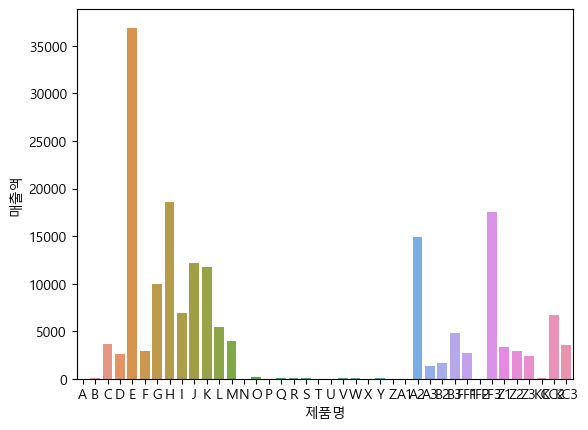

In [112]:
# 제품별 매출액
sns.barplot(data=df3, x='제품명', y='매출액', errorbar=('ci', False));

## **전처리 종합 실습2**
- 제품별 연도/월별 매출액 테이블
- 제품별 연도별 매출액 합계, 증감액, 증감율 데이터 확인
- 증감율 상위 10개 항목 확인

In [115]:
df3.head()

,제품명,일자,매출액
0,A,2019-12-01 00:00:00,0.0
1,B,2019-12-01 00:00:00,0.0
2,C,2019-12-01 00:00:00,9474.3
3,D,2019-12-01 00:00:00,7702.6
4,E,2019-12-01 00:00:00,56309.6


#### **step 2: 날짜 데이터로 전환하기**

In [118]:
# 날짜 데이터로 전환하기
df3['일자(dt)']= pd.to_datetime(df3['일자'])

,제품명,일자,매출액,일자(dt)
0,A,2019-12-01 00:00:00,0.0,2019-12-01 00:00:00.000
1,B,2019-12-01 00:00:00,0.0,2019-12-01 00:00:00.000
2,C,2019-12-01 00:00:00,9474.3,2019-12-01 00:00:00.000
3,D,2019-12-01 00:00:00,7702.6,2019-12-01 00:00:00.000
4,E,2019-12-01 00:00:00,56309.6,2019-12-01 00:00:00.000
...,...,...,...,...
635,Z2,2020-12-01 00:00:00.3,1619.5,2020-12-01 00:00:00.300
636,Z3,2020-12-01 00:00:00.3,3191.2,2020-12-01 00:00:00.300
637,KC,2020-12-01 00:00:00.3,0.0,2020-12-01 00:00:00.300
638,KC2,2020-12-01 00:00:00.3,16845.8,2020-12-01 00:00:00.300


In [119]:
# 연도, 월 컬럼 추가히가
df3['연도'] = df3['일자(dt)'].dt.year
df3['월'] = df3['일자(dt)'].dt.month
df3

,제품명,일자,매출액,일자(dt),연도,월
0,A,2019-12-01 00:00:00,0.0,2019-12-01 00:00:00.000,2019,12
1,B,2019-12-01 00:00:00,0.0,2019-12-01 00:00:00.000,2019,12
2,C,2019-12-01 00:00:00,9474.3,2019-12-01 00:00:00.000,2019,12
3,D,2019-12-01 00:00:00,7702.6,2019-12-01 00:00:00.000,2019,12
4,E,2019-12-01 00:00:00,56309.6,2019-12-01 00:00:00.000,2019,12
...,...,...,...,...,...,...
635,Z2,2020-12-01 00:00:00.3,1619.5,2020-12-01 00:00:00.300,2020,12
636,Z3,2020-12-01 00:00:00.3,3191.2,2020-12-01 00:00:00.300,2020,12
637,KC,2020-12-01 00:00:00.3,0.0,2020-12-01 00:00:00.300,2020,12
638,KC2,2020-12-01 00:00:00.3,16845.8,2020-12-01 00:00:00.300,2020,12


#### **step 3: 제품별 연도/월별 매출액 테이블 만들기**

In [122]:
df3.pivot_table(index=['연도', '월'], values='매출액', columns='제품명', aggfunc='sum')

제품명          A   A1       A2       A3      B       B2       B3        C  \
연도   월                                                                    
2019 12  197.6  8.8  36546.0  20564.1  787.4   1039.0  19498.5  18961.4   
2020 10    0.0  0.0  77843.2     40.0    0.0   2356.8  24025.6  19483.4   
     11    0.0  0.0  55878.8     40.0    0.0    240.8  18963.8  13944.1   
     12    0.0  0.0  68027.4     40.0    0.0  23212.6  14918.0   6736.4   

제품명            D         E  ...     T     U       V      W      X       Y  \
연도   월                      ...                                             
2019 12  15420.6  113205.2  ...  63.6  38.0  1487.8  796.7  199.8  1108.3   
2020 10  12254.6  156536.0  ...   0.0   0.0     0.0    0.0    0.0     0.0   
     11   8019.8  149884.4  ...   0.0   0.0     0.0    0.0    0.0     0.0   
     12   5360.1  169934.5  ...   0.0   0.0     0.0    0.0    0.0     0.0   

제품명          Z       Z1       Z2       Z3  
연도   월                                     
2019 12  165.4      0.0  19340.4  16074.8  
2020 10    0.0  23928.4  12713.7   7966.2  
     11    0.0  16135.6  10684.8   7174.4  
     12    0.0  12836.4   3239.0   6382.4  

[4 rows x 40 columns]

#### **step 4**
- 제품별 연도별 매출액 합계, 증가액, 증감율 열 추가 테이블
- 증감율 상위 10개 행

In [125]:
# 제품별 매출 함계 피벗 테이블 
df4 = df3.pivot_table(index='제품명', values='매출액', columns='연도', aggfunc='sum')
df4

연도,2019,2020
제품명,,
A,197.6,0.0
A1,8.8,0.0
A2,36546.0,201749.4
A3,20564.1,120.0
B,787.4,0.0
B2,1039.0,25810.2
B3,19498.5,57907.4
C,18961.4,40163.9
D,15420.6,25634.5


In [127]:
# 증가액 열 추가
df4['증가액'] = df4[2020] - df4[2019]
df4

연도,2019,2020,증가액
제품명,,,
A,197.6,0.0,-197.6
A1,8.8,0.0,-8.8
A2,36546.0,201749.4,165203.4
A3,20564.1,120.0,-20444.1
B,787.4,0.0,-787.4
B2,1039.0,25810.2,24771.2
B3,19498.5,57907.4,38408.9
C,18961.4,40163.9,21202.5
D,15420.6,25634.5,10213.9


In [130]:
# 증가율 열 추가
df4['증가율'] = (df4['증가액']/df4[2019])
df4

연도,2019,2020,증가액,증가율
제품명,,,,
A,197.6,0.0,-197.6,-1.000000
A1,8.8,0.0,-8.8,-1.000000
A2,36546.0,201749.4,165203.4,4.520424
A3,20564.1,120.0,-20444.1,-0.994165
B,787.4,0.0,-787.4,-1.000000
B2,1039.0,25810.2,24771.2,23.841386
B3,19498.5,57907.4,38408.9,1.969839
C,18961.4,40163.9,21202.5,1.118193
D,15420.6,25634.5,10213.9,0.662354


In [133]:
# 내림 차순 정렬하기
조건1 = df4[2019] > 0 
df4[조건1].sort_values(by='증가율',ascending=False).head(10)

연도,2019,2020,증가액,증가율
제품명,,,,
M,28.0,63871.4,63843.4,2280.121429
B2,1039.0,25810.2,24771.2,23.841386
L,11923.0,75374.2,63451.2,5.321748
F,6363.6,39728.4,33364.8,5.243070
A2,36546.0,201749.4,165203.4,4.520424
H,52483.6,245274.0,192790.4,3.673346
J,35264.4,158978.1,123713.7,3.508175
E,113205.2,476354.9,363149.7,3.207889
B3,19498.5,57907.4,38408.9,1.969839
